# Investigating the Testing of OCSVM Models on Scenarios with/without Interference <br>
Date: 12/08/2024

## Imports

In [1]:
import pandas as pd
import numpy as np 
import math
import os
import gc 
import glob
from pickle import load
from tqdm import tqdm
from datetime import datetime
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.svm import OneClassSVM
from sys import getsizeof
from scipy import special
import matplotlib.pyplot as plt
from pandarallel import pandarallel
from itertools import product

def q_func(x):
    q = 0.5 - 0.5*special.erf(x / np.sqrt(2))
    return q

def friis_calc(P,freq,dist,ple):
    '''
    Friis path loss equation
    P = Tx transmit power
    freq = Signal frequency
    dist = Transmission distance
    ple = Path loss exponent
    '''
    propagation_speed = 299792458
    l = propagation_speed / freq
    h_pl = P * l**2 / (16*math.pi**2)
    P_Rx = h_pl * dist**(-ple)
    return P_Rx

def plos_calc(h_dist, height_tx, height_rx, env='suburban'):
    '''
    % This function implements the LoS probability model from the paper
    % "Blockage Modeling for Inter-layer UAVs Communications in Urban
    % Environments" 
    % param h_dist    : horizontal distance between Tx and Rx (m)
    % param height_tx : height of Tx
    % param height_rx : height of Rx
    '''
    if env == 'suburban':
        a1 = 0.1
        a2 = 7.5e-4
        a3 = 8
    
    delta_h = height_tx - height_rx
    # pow_factor = 2 * h_dist * math.sqrt(a1*a2/math.pi) + a1 # NOTE: Use this pow_factor if assuming PPP building dist.
    pow_factor = h_dist * math.sqrt(a1*a2) # NOTE: Use this pow_factor if assuming ITU-R assumptions.
    if delta_h == 0:
        p = (1 - math.exp((-(height_tx)**2) / (2*a3**2))) ** pow_factor
    else:
        delta_h = abs(delta_h)
        p = (1 - (math.sqrt(2*math.pi)*a3 / delta_h) * abs(q_func(height_tx/a3) - q_func(height_rx/a3))) ** pow_factor
    return p

def sinr_lognormal_approx(h_dist, height, env='suburban'):
    '''
    To approximate the SNR from signal considering multipath fading and shadowing
    Assuming no interference due to CSMA, and fixed noise
    Inputs:
    h_dist = Horizontal Distance between Tx and Rx
    height = Height difference between Tx and Rx
    env = The operating environment (currently only suburban supported)
    '''
    # Signal properties
    P_Tx_dBm = 20 # Transmit power of 
    P_Tx = 10**(P_Tx_dBm/10) / 1000
    freq = 2.4e9 # Channel frequency (Hz)
    noise_dBm = -86
    noise = 10**(noise_dBm/10) / 1000
    if env == "suburban":
        # ENV Parameters Constants ----------------------------------
        # n_min = 2
        # n_max = 2.75
        # K_dB_min = 7.8
        # K_dB_max = 17.5
        # K_min = 10**(K_dB_min/10)
        # K_max = 10**(K_dB_max/10)
        # alpha = 11.25 # Env parameters for logarithm std dev of shadowing 
        # beta = 0.06 # Env parameters for logarithm std dev of shadowing 
        n_min = 2
        n_max = 2.75
        K_dB_min = 1.4922
        K_dB_max = 12.2272
        K_min = 10**(K_dB_min/10)
        K_max = 10**(K_dB_max/10)
        alpha = 11.1852 # Env parameters for logarithm std dev of shadowing 
        beta = 0.06 # Env parameters for logarithm std dev of shadowing 
        # -----------------------------------------------------------
    # Calculate fading parameters
    PLoS = plos_calc(h_dist, 0, height, env='suburban')
    theta_Rx = math.atan2(height, h_dist) * 180 / math.pi # Elevation angle in degrees
    ple = (n_min - n_max) * PLoS + n_max # Path loss exponent
    sigma_phi_dB = alpha*math.exp(-beta*theta_Rx)
    sigma_phi = 10**(sigma_phi_dB/10) # Logarithmic std dev of shadowing
    K = K_min * math.exp(math.log(K_max/K_min) * PLoS**2)
    omega = 1 # Omega of NCS (Rician)
    dist = math.sqrt(h_dist**2 + height**2)
    P_Rx = friis_calc(P_Tx, freq, dist, ple)
    # Approximate L-NCS RV (which is the SNR) as lognormal
    eta = math.log(10) / 10
    mu_phi = 10*math.log10(P_Rx)
    E_phi = math.exp(eta*mu_phi + eta**2*sigma_phi**2/2) # Mean of shadowing RV
    var_phi = math.exp(2*eta*mu_phi+eta**2*sigma_phi**2)*(math.exp(eta**2*sigma_phi**2)-1) # Variance of shadowing RV
    E_chi = (special.gamma(1+1)/(1+K))*special.hyp1f1(-1,1,-K)*omega
    var_chi = (special.gamma(1+2)/(1+K)**2)*special.hyp1f1(-2,1,-K)*omega**2 - E_chi**2
    E_SNR = E_phi * E_chi / noise # Theoretical mean of SINR
    var_SNR = ((var_phi+E_phi**2)*(var_chi+E_chi**2) - E_phi**2 * E_chi**2) / noise**2
    std_dev_SNR = math.sqrt(var_SNR)
    # sigma_ln = math.sqrt(math.log(var_SNR/E_SNR**2 + 1))
    # mu_ln = math.log(E_SNR) - sigma_ln**2/2
    return E_SNR, std_dev_SNR

def get_measured_throughput(sim_root_path, link="Downlink", single_path = False):
    '''
    Function to load the processed measured throughput data from CSV files stored in different subdirs in sim_root_path
    Modified: The throughput files for each UAV and the GCS are stored separately (rather than single Uplink/Downlink) and separated by runs.
    '''
    assert link in ["Downlink", "Uplink", "Video"], 'link must be one of "Downlink", "Uplink", "Video"'
    df_list = []
    if single_path:
        scenario_list = [sim_root_path]
    else:
        scenario_list = [f.path for f in os.scandir(sim_root_path) if f.is_dir()] # Get list of "unique" scenarios
    for scenario in tqdm(scenario_list):
        # Get the measured throughput samples for UL/DL/Vid under this scenario
        if link == "Downlink":
            throughput_files = glob.glob(os.path.join(scenario, "Run-*_Downlink_Throughput.csv"))
        elif link == "Uplink":
            throughput_files = glob.glob(os.path.join(scenario, "Run-*_Uplink_Throughput.csv"))
        elif link == "Video":
            throughput_files = glob.glob(os.path.join(scenario, "Run-*_Video_Throughput.csv"))
        
        for file in throughput_files:
            measured_df = pd.read_csv(file)
            df_list.append(measured_df)

    return pd.concat(df_list)

def normalize_data(df_in, columns, link, save_details_path=None):
    '''
    columns: The pandas data columns to normalize, given as a list of column names
    link is the link type, for choosing the range of measured throughput to scale the data
    '''
    assert link in ["Downlink", "Uplink", "Video"], 'link must be one of "Downlink", "Uplink", "Video"'
    df = df_in.copy()
    # Define the ranges of parametrers
    max_mean_sinr = 10*math.log10(1123) # The max mean SINR calculated at (0,60) is 1122.743643457063 (linear)
    max_std_dev_sinr = 10*math.log10(466) # The max std dev SINR calculated at (0,60) is 465.2159856885714 (linear)
    min_mean_sinr = 10*math.log10(0.2) # The min mean SINR calculated at (1200,60) is 0.2251212887895188 (linear)
    min_std_dev_sinr = 10*math.log10(0.7) # The min std dev SINR calculated at (1200,300) is 0.7160093126585219 (linear)
    max_height = 300
    min_height = 60
    max_h_dist = 1200
    min_h_dist = 0
    max_mcs = 7
    min_mcs = 0
    max_uav_speed = 26
    min_uav_speed = 0
    if link == "Downlink":
        max_throughput = 16000 # Max measured throughput for DJI Spark Downlink is 15968 bytes/sec
    elif link == "Uplink":
        max_throughput = 565000 # Max measured throughput for DJI Spark Uplink is 564990 bytes/sec
    elif link == "Video":
        max_throughput = 300000 # Max measured throughput for DJI Spark Video Link is 298700 bytes/sec
    min_throughput = 0

    # Normalize data (Min Max Normalization between [-1,1])
    if "Height" in columns:
        df["Height"] = df["Height"].apply(lambda x: 2*(x-min_height)/(max_height-min_height) - 1)
    if "U2G_H_Dist" in columns:
        df["U2G_H_Dist"] = df["U2G_H_Dist"].apply(lambda x: 2*(x-min_h_dist)/(max_h_dist-min_h_dist) - 1)
    if "Horizontal_Distance" in columns:
        df["Horizontal_Distance"] = df["Horizontal_Distance"].apply(lambda x: 2*(x-min_h_dist)/(max_h_dist-min_h_dist) - 1)
    if "Mean_SINR" in columns:
        df["Mean_SINR"] = df["Mean_SINR"].apply(lambda x: 2*(10*math.log10(x)-min_mean_sinr)/(max_mean_sinr-min_mean_sinr) - 1) # Convert to dB space
    if "Std_Dev_SINR" in columns:
        df["Std_Dev_SINR"] = df["Std_Dev_SINR"].apply(lambda x: 2*(10*math.log10(x)-min_std_dev_sinr)/(max_std_dev_sinr-min_std_dev_sinr) - 1) # Convert to dB space
    if "UAV_Sending_Interval" in columns:
        df["UAV_Sending_Interval"] = df["UAV_Sending_Interval"].replace({10:-1, 20:-0.5, 40:0, 66.7: 0.5, 100:1, 1000:2})
    if "Packet_State" in columns:
        df['Packet_State'] = df['Packet_State'].replace({"Reliable":0, "QUEUE_OVERFLOW":1, "RETRY_LIMIT_REACHED":2, "Delay_Exceeded":3})
    if "Modulation" in columns:
        df['Modulation'] = df['Modulation'].replace({"BPSK":1, "QPSK":0.3333, 16:-0.3333, "QAM-16":-0.3333, "QAM16":-0.3333, 64:-1, "QAM-64":-1, "QAM64":-1})
    if "MCS" in columns:
        df["MCS"] = df["MCS"].apply(lambda x: 2*(x-min_mcs)/(max_mcs-min_mcs) - 1)
    if "MCS_Index" in columns:
        df["MCS_Index"] = df["MCS_Index"].apply(lambda x: 2*(x-min_mcs)/(max_mcs-min_mcs) - 1)
    if "UAV_Speed" in columns:
        df["UAV_Speed"] = df["UAV_Speed"].apply(lambda x: 2*(x-min_uav_speed)/(max_uav_speed-min_uav_speed) - 1)
    if "Throughput" in columns:
        df["Throughput"] = df["Throughput"].apply(lambda x: 2*(x-min_throughput)/(max_throughput-min_throughput) - 1)


    # Record details of inputs and output for model
    if save_details_path is not None:
        f = open(os.path.join(save_details_path,"model_details.txt"), "w")
        f.write("Max Height (m): {}\n".format(max_height))
        f.write("Min Height (m): {}\n".format(min_height))
        f.write("Max H_Dist (m): {}\n".format(max_h_dist))
        f.write("Min H_Dist (m): {}\n".format(min_h_dist))
        f.write("Max Mean SINR (dB): {}\n".format(max_mean_sinr))
        f.write("Min Mean SINR (dB): {}\n".format(min_mean_sinr))
        f.write("Max Std Dev SINR (dB): {}\n".format(max_std_dev_sinr))
        f.write("Min Std Dev SINR (dB): {}\n".format(min_std_dev_sinr))
        f.write("Max UAV Speed (m/s): {}\n".format(max_uav_speed))
        f.write("Min UAV Speed (m/s): {}\n".format(min_uav_speed))
        f.write("Max Measured Throughput (bytes/sec): {}\n".format(max_throughput))
        f.write("Min Measured Throughput (bytes/sec): {}\n".format(min_throughput))
        f.write("[BPSK: 1, QPSK: 0.3333, QAM16: -0.3333, QAM64: -1]\n")
        f.write("UAV Sending Interval: [10:-1, 20:-0.5, 40:0, 66.7: 0.5, 100:1, 1000:2]\n")
        f.write("Output: ['Reliable':0, 'QUEUE_OVERFLOW':1, 'RETRY_LIMIT_REACHED':2, 'Delay_Exceeded':3]\n")
        f.close()

    return df

def get_mcs_index(df_in):
    '''
    Gets the MCS index based on modulation and bitrate column of the df_in
    '''
    df = df_in.copy()
    df["MCS"] = ''
    df.loc[(df["Modulation"] == "BPSK") & (df["Bitrate"] == 6.5), "MCS"] = 0 # MCS Index 0
    df.loc[(df["Modulation"] == "QPSK") & (df["Bitrate"] == 13), "MCS"] = 1 # MCS Index 1
    df.loc[(df["Modulation"] == "QPSK") & (df["Bitrate"] == 19.5), "MCS"] = 2 # MCS Index 2
    df.loc[(df["Modulation"] == "QAM16") & (df["Bitrate"] == 26), "MCS"] = 3 # MCS Index 3
    df.loc[(df["Modulation"] == "QAM16") & (df["Bitrate"] == 39), "MCS"] = 4 # MCS Index 4
    df.loc[(df["Modulation"] == "QAM64") & (df["Bitrate"] == 52), "MCS"] = 5 # MCS Index 5
    df.loc[(df["Modulation"] == "QAM64") & (df["Bitrate"] == 58.5), "MCS"] = 6 # MCS Index 6
    df.loc[(df["Modulation"] == "QAM64") & (df["Bitrate"] == 65), "MCS"] = 7 # MCS Index 7

    return df

def norm_MCS(mcs_index):
    return 2*mcs_index/7 - 1

def get_MCS_bitrate(mcs_index):
    mcs_bitrate = {0: 6.5, 1: 13, 2: 19.5, 3: 26, 4: 39, 5: 52, 6: 58.5, 7: 65}
    return mcs_bitrate[mcs_index]

def get_MCS_index(mcs_bitrate):
    mcs_index = {6.5: 0, 13: 1, 19.5: 2, 26: 3, 39: 4, 52: 5, 58.5: 6, 65: 7}
    return mcs_index[mcs_bitrate]

## Set Model and Dataset Paths

In [19]:
OCSVM_MODEL_PATH = "/media/research-student/KingstonSSD/ocsvm_models"
ROBUST_SCALER_PATH = "/media/research-student/KingstonSSD/ocsvm_models"
DMAX_FILE = "/home/research-student/omnet-fanet/data-processing-scripts/ocsvm_critical_distances/Dmax_RelTh99_Simulated_Reliability_v3_10e5.csv" 

# For parallel_apply
WORKERS = 12
pandarallel.initialize(nb_workers=WORKERS, progress_bar=False)

INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


## Test No Interference

In [20]:
# Set parameters
uav_speed = 16
height = 90
usi = 20
bitrate = 13
modulation = "QPSK"
run_num = 0
link = "Video" # UAV-0_Downlink, ..., UAV-7_Downlink, Uplink, Video
ocsvm_link = "Video" # For ocsvm model path
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_ocsvm_train_processed" 

mcs_index = get_MCS_index(bitrate)
# Load model and robust scaler
ocsvm_model = load(open(os.path.join(OCSVM_MODEL_PATH, "ocsvm_{}_USI-{}_MCS-{}.pkl".format(ocsvm_link, usi, mcs_index)), 'rb'))
robust_scaler = load(open(os.path.join(ROBUST_SCALER_PATH, "robust_scaler_{}_USI-{}_MCS-{}.pkl".format(ocsvm_link, usi, mcs_index)), 'rb'))

# Load dataset
path = glob.glob(os.path.join(DATASET_PATH, "UAVSpeed-{}_BitRate-{}_Height-{}_Distance-*_Modulation-{}_UAVSendingInterval-{}").format(uav_speed, bitrate, height, modulation, usi))[0]
test_throughput_no_int_df = pd.read_csv(os.path.join(path, "Run-{}_{}_Throughput.csv".format(run_num, link)))

# Filter by crit dist (might not be needed if dataset generated up to dmax only)
dmax_df = pd.read_csv(DMAX_FILE)
dmax = dmax_df.loc[(dmax_df["MCS_Index"] == mcs_index) & (dmax_df["USI"] == usi) & (dmax_df["Height"] == height)]["D_max"].values[0]
test_throughput_no_int_df = test_throughput_no_int_df.loc[test_throughput_no_int_df["Horizontal_Distance"] <= dmax]

# Process test data
throughput = np.array(test_throughput_no_int_df["Throughput"].values)
test_throughput_no_int_df["Throughput_Norm"] = robust_scaler.transform(throughput.reshape(-1,1))           
test_throughput_no_int_df[['Mean_SINR',"Std_Dev_SINR"]] = test_throughput_no_int_df.parallel_apply(lambda row: sinr_lognormal_approx(row['Horizontal_Distance'],row['Height']),axis=1,result_type='expand')
test_throughput_no_int_df = normalize_data(test_throughput_no_int_df, columns=["Mean_SINR", "Std_Dev_SINR",], link=ocsvm_link)

X_test_no_int = test_throughput_no_int_df[["Mean_SINR", "Std_Dev_SINR", "Throughput_Norm"]].values
y_pred_no_int_ocsvm = ocsvm_model.predict(X_test_no_int)
y_pred_no_int_ocsvm = (y_pred_no_int_ocsvm + 1) // 2 # To convert the range from -1:1 to 0:1 (0 for outlier, 1 for inlier)
non_anomalous_accuracy_score_ocsvm = np.sum(y_pred_no_int_ocsvm) / len(X_test_no_int) # Ground truth is all 1 for normal test data

/home/research-student/tf_venv/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.0.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Plot contour

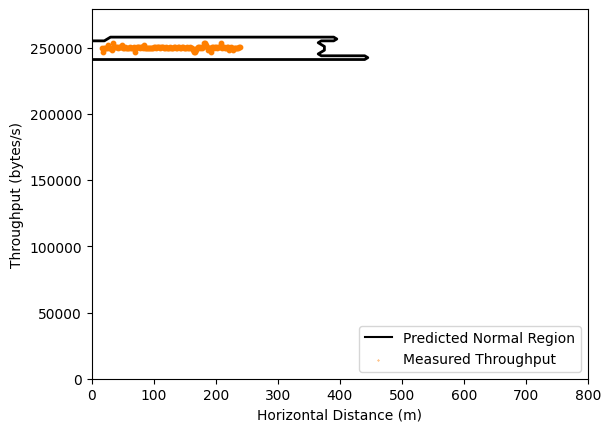

In [21]:
max_mean_sinr = 10*math.log10(1123) # The max mean SINR calculated at (0,60) is 1122.743643457063 (linear)
max_std_dev_sinr = 10*math.log10(466) # The max std dev SINR calculated at (0,60) is 465.2159856885714 (linear)
min_mean_sinr = 10*math.log10(0.2) # The min mean SINR calculated at (1200,60) is 0.2251212887895188 (linear)
min_std_dev_sinr = 10*math.log10(0.7) # The min std dev SINR calculated at (1200,300) is 0.7160093126585219 (linear)
max_h_dist = 1200
min_h_dist = 0
max_uav_speed = 26
min_uav_speed = 0
max_throughput = np.max([(robust_scaler.center_ + 20.5 * robust_scaler.scale_)[0], test_throughput_no_int_df["Throughput"].max()])
min_throughput = np.min([(robust_scaler.center_ - 1.5 * robust_scaler.scale_)[0], test_throughput_no_int_df["Throughput"].min(), 0])

xx, yy = np.meshgrid(np.linspace(min_h_dist, max_h_dist, 121), np.linspace(min_throughput, max_throughput, 100))
_, yy_norm = np.meshgrid(np.linspace(min_h_dist, max_h_dist, 121), np.linspace(robust_scaler.transform([[min_throughput]]), robust_scaler.transform([[max_throughput]]), 100))
# yy_norm = 2*yy/max_throughput - 1
mean_sinr = []
std_dev_sinr = []
for x in xx.ravel():
    m, s = sinr_lognormal_approx(x, height)
    m = 2*(10*math.log10(m)-min_mean_sinr)/(max_mean_sinr-min_mean_sinr) - 1
    s = 2*(10*math.log10(s)-min_std_dev_sinr)/(max_std_dev_sinr-min_std_dev_sinr) - 1
    mean_sinr.append(m)
    std_dev_sinr.append(s)
# Get contour for model
Z1 = ocsvm_model.predict(np.c_[mean_sinr, std_dev_sinr, yy_norm.ravel()])
Z1 = Z1.reshape(xx.shape)
plt.contour(xx, yy, Z1, levels=[0], linewidths=2, colors="black")

# Run inference on test data in previous code block first!!!
colors = np.array(["#377eb8", "#ff7f00"])
plt.scatter(test_throughput_no_int_df["Horizontal_Distance"].values, test_throughput_no_int_df["Throughput"].values, s=10, color='#ff7f00', label="_nolegend_")
plt.plot([0], [0], color='k')
plt.scatter([0], [0], s=0.1, color='#ff7f00')
# plt.scatter([0], [0], s=10, color='#377eb8')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Throughput (bytes/s)")
plt.xlim((0, 800))
plt.ylim((min_throughput, max_throughput))
plt.legend(["Predicted Normal Region", "Measured Throughput"], loc='lower right')
# plt.title("UAVSpeed-{}_BitRate-{}_Height-{}_Modulation-{}_UAVSendingInterval-{}".format(uav_speed, bitrate, height, modulation, usi))

## Test UAV Interference

In [5]:
# Set parameters
uav_speed = 16
height = 150
usi = 100
bitrate = 26
modulation = "QAM-16"
run_num = 0
link = "UAV-0_Downlink" # UAV-0_Downlink, ..., UAV-7_Downlink, Uplink, Video
ocsvm_link = "Downlink" # For ocsvm model path

DATASET_PATH = os.path.join("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Manual_Control_UAV_Interference/default_processed/",
                            "UAVSpeed-16_BitRate-26_Height-150_InterferenceDistance-0_Modulation-QAM-16_UAVSendingInterval-100_UAVGCSInterfererDist-0_InterferenceBitRate-26_InterferenceHeight-150")

mcs_index = get_MCS_index(bitrate)
# Load model and robust scaler
ocsvm_model = load(open(os.path.join(OCSVM_MODEL_PATH, "ocsvm_{}_USI-{}_MCS-{}.pkl".format(ocsvm_link, usi, mcs_index)), 'rb'))
robust_scaler = load(open(os.path.join(ROBUST_SCALER_PATH, "robust_scaler_{}_USI-{}_MCS-{}.pkl".format(ocsvm_link, usi, mcs_index)), 'rb'))

# Load dataset
# path = glob.glob(os.path.join(DATASET_PATH, "UAVSpeed-{}_BitRate-{}_Height-{}_Distance-*_Modulation-{}_UAVSendingInterval-{}").format(uav_speed, bitrate, height, modulation, usi))[0]
test_throughput_no_int_df = pd.read_csv(os.path.join(DATASET_PATH, "Run-{}_{}_Throughput.csv".format(run_num, link)))

# Filter by crit dist (might not be needed if dataset generated up to dmax only)
dmax_df = pd.read_csv(DMAX_FILE)
dmax = dmax_df.loc[(dmax_df["MCS_Index"] == mcs_index) & (dmax_df["USI"] == usi) & (dmax_df["Height"] == height)]["D_max"].values[0]
test_throughput_no_int_df = test_throughput_no_int_df.loc[test_throughput_no_int_df["Horizontal_Distance"] <= dmax]

# Process test data
throughput = np.array(test_throughput_no_int_df["Throughput"].values)
test_throughput_no_int_df["Throughput_Norm"] = robust_scaler.transform(throughput.reshape(-1,1))           
test_throughput_no_int_df[['Mean_SINR',"Std_Dev_SINR"]] = test_throughput_no_int_df.parallel_apply(lambda row: sinr_lognormal_approx(row['Horizontal_Distance'],row['Height']),axis=1,result_type='expand')
test_throughput_no_int_df = normalize_data(test_throughput_no_int_df, columns=["Mean_SINR", "Std_Dev_SINR",], link=ocsvm_link)

X_test_no_int = test_throughput_no_int_df[["Mean_SINR", "Std_Dev_SINR", "Throughput_Norm"]].values
y_pred_no_int_ocsvm = ocsvm_model.predict(X_test_no_int)
y_pred_no_int_ocsvm = (y_pred_no_int_ocsvm + 1) // 2 # To convert the range from -1:1 to 0:1 (0 for outlier, 1 for inlier)
non_anomalous_accuracy_score_ocsvm = np.sum(y_pred_no_int_ocsvm) / len(X_test_no_int) # Ground truth is all 1 for normal test data

FileNotFoundError: [Errno 2] No such file or directory: '/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Manual_Control_UAV_Interference/default_processed/UAVSpeed-16_BitRate-26_Height-150_InterferenceDistance-0_Modulation-QAM-16_UAVSendingInterval-100_UAVGCSInterfererDist-0_InterferenceBitRate-26_InterferenceHeight-150/Run-0_UAV-0_Downlink_Throughput.csv'